RAW SCORES: [0.07435246 0.06483421 0.06478129 0.06476304 0.06360071 0.06358875
 0.06356993 0.06351066 0.06346195 0.06259584 0.06250081 0.06236301
 0.0620795  0.06189953 0.06188852 0.06188492 0.06186188 0.06167683
 0.06125114 0.06101882 0.06092943 0.06043669 0.05982041 0.05946493
 0.05907664 0.05905    0.05878608 0.05852121 0.05832951 0.05811694
 0.05752315 0.05739207 0.05737672 0.05715932 0.05710915 0.05707997
 0.05707845 0.05704766 0.05661324 0.05657256 0.05636166 0.05627358
 0.0561673  0.05610019 0.05604362 0.05602491 0.05602316 0.05569251
 0.05551402 0.05530916 0.05515618 0.05499694 0.05487173 0.05478163
 0.05463916 0.05463227 0.05454754 0.05431454 0.05425474 0.05424874
 0.05405857 0.05363434 0.05358704 0.05354337 0.05353415 0.05345373
 0.05338469 0.05322602 0.05318611 0.05300673 0.05290275 0.05285082
 0.05276097 0.05272214 0.05262851 0.05238466 0.05237345 0.05204942
 0.05179198 0.05161633 0.05141246 0.05132577 0.05119649 0.05103756
 0.05036455 0.05006758 0.05003742 0.05003161]
NUMB

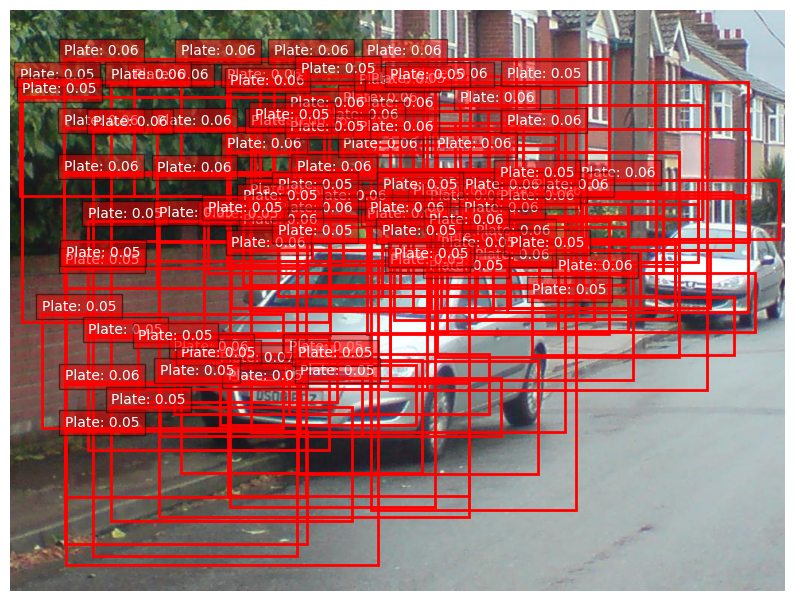

In [ ]:
import torch
from PIL import Image
import torchvision.transforms as T
from torchvision.models.detection import fasterrcnn_resnet50_fpn
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Load your real-world image
image_path = r"..\data\formatted\license_plate_detection\test\images\lp_test_image001.jpg"
img = Image.open(image_path).convert("RGB")

# 2. Transform pipeline 
# (ONLY ToTensor is needed; Faster R-CNN handles the 800/1333 resize & ImageNet normalization internally)
transform = T.Compose([
    T.ToTensor()
])

# Transform and add a batch dimension (B, C, H, W)
input_tensor = transform(img).unsqueeze(0)

# 3. Instantiate the model architecture 
# (2 classes: 1 for the license plate + 1 for the background)
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# 1. Define the exact same setup function in your inference script
def get_object_detection_model(num_classes):
    # Load the base COCO model structure
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    # Get the input features
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # Replace the head
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

# 2. Instantiate using your function
model = get_object_detection_model(num_classes=2)

# 3. Now load your weights safely
weights_path = r"..\models\custom_faster_rcnn.pt"
model.load_state_dict(torch.load(weights_path, map_location=torch.device('cpu')))
model.eval()
# CRITICAL: Set the model to evaluation mode
model.eval()

# 5. Move to GPU if available, otherwise stick to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
input_tensor = input_tensor.to(device)

# 6. Run Inference
with torch.no_grad():
    predictions = model(input_tensor)

# 7. Post-Process and Plot Bounding Boxes
# Extract boxes, labels, and scores
boxes = predictions[0]['boxes'].cpu().numpy()
labels = predictions[0]['labels'].cpu().numpy()
scores = predictions[0]['scores'].cpu().numpy()

print("RAW SCORES:", predictions[0]['scores'].cpu().numpy())
print("NUMBER OF BOXES FOUND:", len(predictions[0]['boxes']))

# Set up the plot
fig, ax = plt.subplots(1, figsize=(10, 10))
ax.imshow(img)

# Filter out low-confidence guesses
CONFIDENCE_THRESHOLD = 0.1

for box, label, score in zip(boxes, labels, scores):
    if score > CONFIDENCE_THRESHOLD:
        xmin, ymin, xmax, ymax = box
        width, height = xmax - xmin, ymax - ymin
        
        # Create a red bounding box
        rect = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        
        # Add a label (Class 1 is your license plate)
        plt.text(xmin, ymin - 5, f"Plate: {score:.2f}", color='white', bbox=dict(facecolor='red', alpha=0.5))

plt.axis('off')
plt.show()